In [1]:
# Export model, Transformer and encoder
import pickle as pkl
pkl.dump(model,open("model.pkl","wb"))
pkl.dump(encoder,open("encoder.pkl",'wb'))


# pkl.dump(featureEncoder,open('feature11.pkl','wb'))
pkl.dump(numCols,open("numCols.pkl","wb"))

NameError: name 'model' is not defined

In [29]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost
from sklearn.utils.class_weight import compute_sample_weight
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,PowerTransformer,StandardScaler,LabelEncoder
from xgboost import XGBClassifier

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_score, accuracy_score,f1_score,fbeta_score
import pandas as pd

In [4]:
weatherData=pd.read_csv("weather-dataset.csv")
# weatherData=weatherData.drop(columns=['date'])

In [5]:
weatherData

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain
...,...,...,...,...,...,...
1456,2015-12-27,8.6,4.4,1.7,2.9,rain
1457,2015-12-28,1.5,5.0,1.7,1.3,rain
1458,2015-12-29,0.0,7.2,0.6,2.6,fog
1459,2015-12-30,0.0,5.6,-1.0,3.4,sun


In [6]:
# Covert date col to datetime to extract Year,Month and day
weatherData['date']=pd.to_datetime(weatherData['date'])

In [7]:
# getYear
weatherData['Year']=weatherData['date'].dt.year

# getMonths
weatherData['Month']=weatherData['date'].dt.month



In [8]:
# get day
weatherData['Day']=weatherData['date'].dt.day


In [ ]:
# weatherData.describe

In [9]:
weatherData.to_csv("test_dataset.csv")


In [10]:
# drop date
weatherData=weatherData.drop(columns=['date'])

In [11]:
# check for null values
weatherData.isnull().sum()

precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
Year             0
Month            0
Day              0
dtype: int64

In [ ]:
# extract columns(num and text cols)
# numCols=[cols for cols in weatherData.columns if weatherData[cols].dtype!="object"]
# numCols=
# textCols=[cols for cols in weatherData.columns if weatherData[cols].dtype in ["int64","float64"]]

In [12]:
weatherData

,precipitation,temp_max,temp_min,wind,weather,Year,Month,Day
0,0.0,12.8,5.0,4.7,drizzle,2012,1,1
1,10.9,10.6,2.8,4.5,rain,2012,1,2
2,0.8,11.7,7.2,2.3,rain,2012,1,3
3,20.3,12.2,5.6,4.7,rain,2012,1,4
4,1.3,8.9,2.8,6.1,rain,2012,1,5
...,...,...,...,...,...,...,...,...
1456,8.6,4.4,1.7,2.9,rain,2015,12,27
1457,1.5,5.0,1.7,1.3,rain,2015,12,28
1458,0.0,7.2,0.6,2.6,fog,2015,12,29
1459,0.0,5.6,-1.0,3.4,sun,2015,12,30


In [13]:
numCols=['precipitation', 'temp_max', 'temp_min', 'wind', 'Year', 'Day']


In [14]:
weatherData.dtypes

precipitation    float64
temp_max         float64
temp_min         float64
wind             float64
weather           object
Year               int32
Month              int32
Day                int32
dtype: object

In [15]:
excludedColumns=['date','Year','Day']

In [16]:
# Numerical cols to deal with
numCols=list(set(numCols)-set(excludedColumns))

In [ ]:
numCols

In [17]:
weatherData

,precipitation,temp_max,temp_min,wind,weather,Year,Month,Day
0,0.0,12.8,5.0,4.7,drizzle,2012,1,1
1,10.9,10.6,2.8,4.5,rain,2012,1,2
2,0.8,11.7,7.2,2.3,rain,2012,1,3
3,20.3,12.2,5.6,4.7,rain,2012,1,4
4,1.3,8.9,2.8,6.1,rain,2012,1,5
...,...,...,...,...,...,...,...,...
1456,8.6,4.4,1.7,2.9,rain,2015,12,27
1457,1.5,5.0,1.7,1.3,rain,2015,12,28
1458,0.0,7.2,0.6,2.6,fog,2015,12,29
1459,0.0,5.6,-1.0,3.4,sun,2015,12,30


In [18]:
# split data
x=weatherData.drop(columns=["weather"])
y=weatherData['weather']
xTrain,xTest,yTrain,yTest=train_test_split(x,y,test_size=0.3,random_state=34)

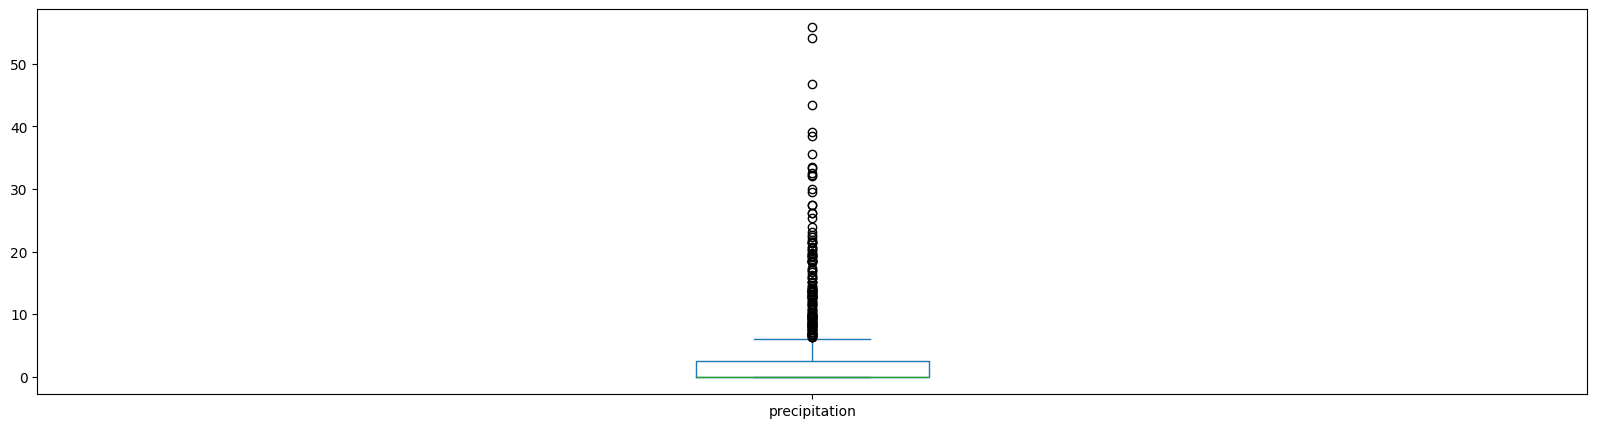

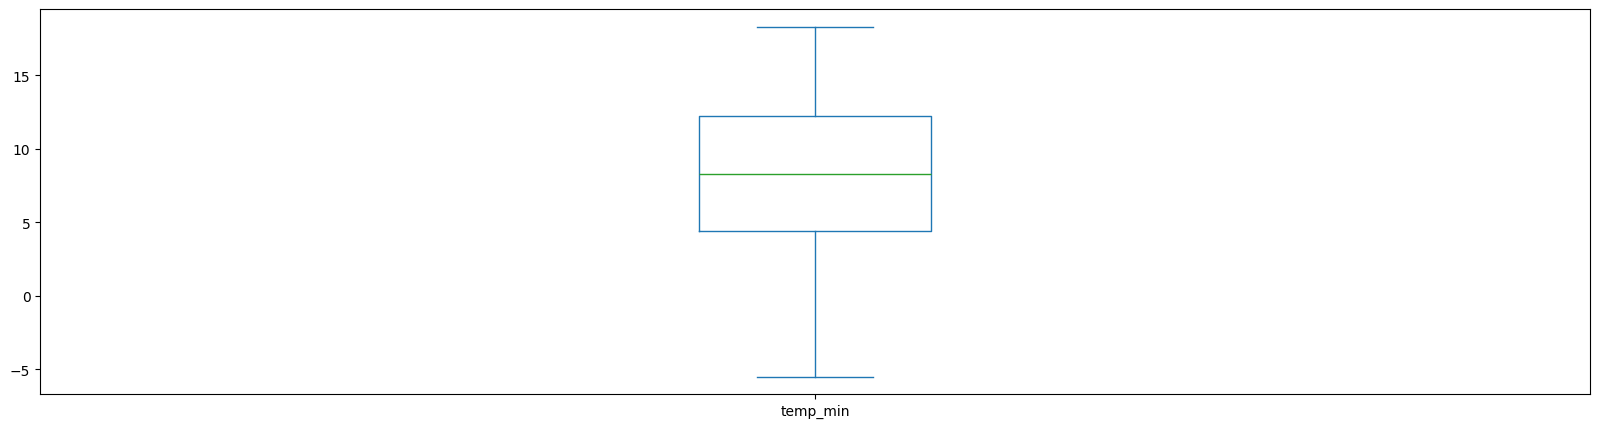

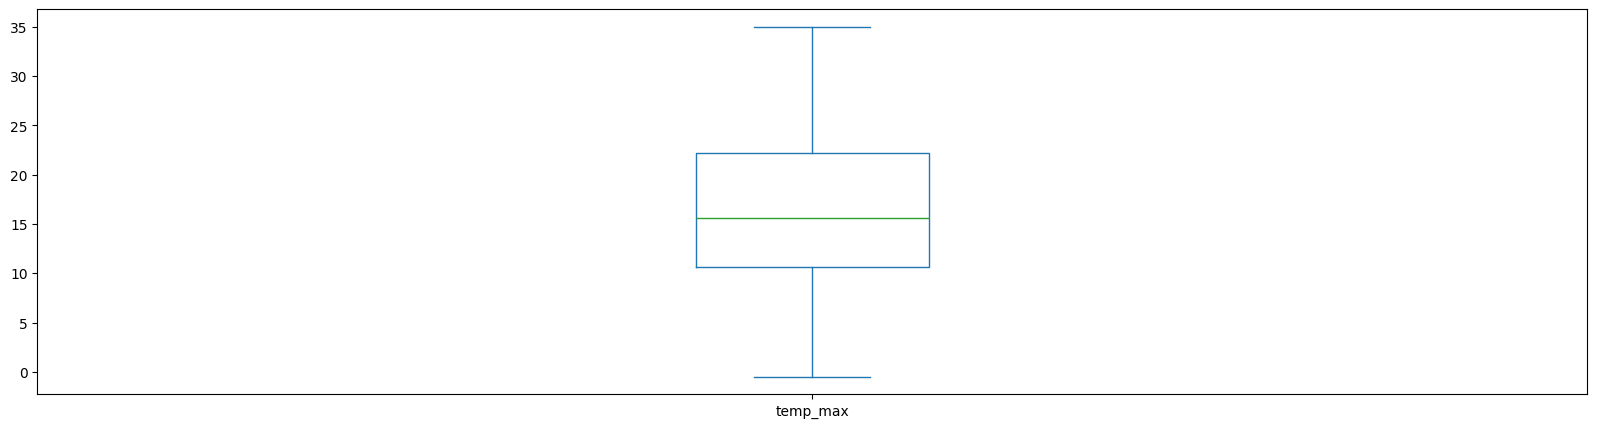

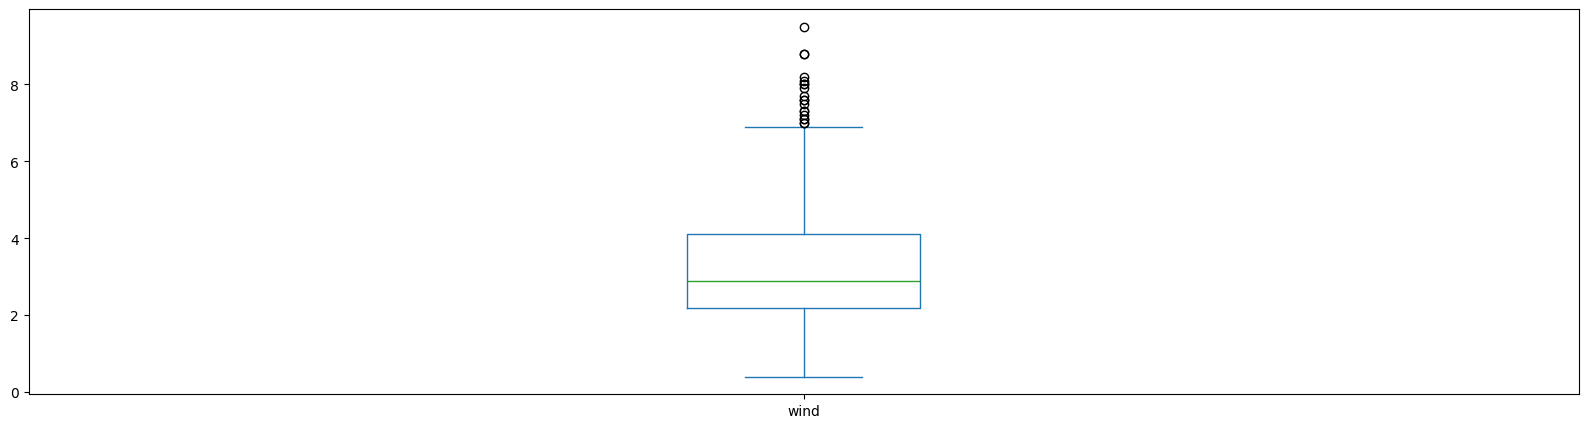

In [19]:
# check outliers
for out in numCols:
    plt.figure(figsize=(20,5))
    xTrain[out].plot(kind="box")

In [20]:
# outliers exists
# handle them
bounds={}
for handleOut in numCols:
    Q1=xTrain[handleOut].quantile(0.25)
    Q3=xTrain[handleOut].quantile(0.75)

    IQR=Q3-Q1
    lowerBound=Q1-1.5*IQR
    upperBound=Q3+1.5*IQR
    
    bounds[handleOut]={"lower":lowerBound,"upper":upperBound}

    xTrain[handleOut]=xTrain[handleOut].clip(lower=lowerBound,upper=upperBound)
    xTest[handleOut]=xTest[handleOut].clip(lower=lowerBound,upper=upperBound)
pkl.dump(bounds,open('bounds.joblib','wb'))

In [21]:
weatherData

,precipitation,temp_max,temp_min,wind,weather,Year,Month,Day
0,0.0,12.8,5.0,4.7,drizzle,2012,1,1
1,10.9,10.6,2.8,4.5,rain,2012,1,2
2,0.8,11.7,7.2,2.3,rain,2012,1,3
3,20.3,12.2,5.6,4.7,rain,2012,1,4
4,1.3,8.9,2.8,6.1,rain,2012,1,5
...,...,...,...,...,...,...,...,...
1456,8.6,4.4,1.7,2.9,rain,2015,12,27
1457,1.5,5.0,1.7,1.3,rain,2015,12,28
1458,0.0,7.2,0.6,2.6,fog,2015,12,29
1459,0.0,5.6,-1.0,3.4,sun,2015,12,30


In [22]:
# encode category
encoder=LabelEncoder()
yTrain=encoder.fit_transform(yTrain)


In [23]:
# encode yTest set
yTest=encoder.transform(yTest)

In [ ]:
encoder.classes_

In [24]:
# encode yTest
yTest

array([2, 4, 2, 4, 1, 4, 4, 4, 4, 2, 2, 0, 2, 4, 4, 4, 4, 4, 4, 4, 2, 4,
       4, 2, 2, 2, 4, 4, 2, 1, 4, 2, 4, 2, 2, 4, 2, 4, 0, 1, 2, 2, 2, 2,
       2, 2, 3, 1, 4, 2, 2, 3, 2, 4, 4, 4, 1, 1, 2, 2, 3, 4, 4, 2, 4, 4,
       2, 4, 2, 4, 2, 2, 4, 4, 1, 4, 4, 4, 0, 2, 3, 2, 4, 1, 2, 2, 4, 2,
       4, 0, 0, 4, 2, 4, 4, 2, 4, 2, 2, 4, 2, 2, 2, 4, 4, 2, 2, 4, 4, 4,
       1, 4, 4, 2, 2, 2, 2, 2, 4, 2, 4, 4, 2, 4, 3, 2, 2, 1, 2, 4, 4, 4,
       4, 4, 3, 2, 2, 4, 1, 2, 4, 2, 4, 2, 4, 4, 2, 4, 4, 0, 4, 4, 2, 4,
       2, 2, 4, 1, 2, 4, 2, 0, 4, 4, 4, 2, 4, 1, 2, 4, 4, 2, 2, 2, 2, 2,
       4, 4, 2, 2, 4, 2, 4, 4, 2, 4, 2, 4, 4, 4, 2, 4, 2, 4, 4, 2, 4, 4,
       4, 2, 4, 2, 2, 4, 4, 4, 0, 2, 4, 4, 2, 2, 2, 2, 4, 4, 2, 2, 2, 2,
       2, 4, 2, 4, 4, 2, 4, 4, 4, 4, 4, 4, 1, 2, 2, 4, 3, 4, 2, 4, 2, 4,
       2, 4, 4, 2, 4, 2, 4, 1, 0, 2, 4, 2, 1, 2, 4, 4, 1, 4, 2, 4, 4, 2,
       2, 1, 4, 2, 2, 4, 2, 2, 4, 4, 2, 2, 4, 2, 2, 2, 4, 4, 0, 1, 2, 4,
       2, 4, 2, 2, 2, 2, 2, 2, 2, 4, 2, 4, 2, 2, 3,

In [25]:
# Combine dataset
xx=pd.DataFrame(xTrain,columns=numCols)
yy=pd.DataFrame(yTrain,columns=["Ycolumn"])
combine=pd.concat([xx.reset_index(drop=True),yy.reset_index(drop=True)],axis=1)
# check correlation
combine.corr()

,precipitation,temp_min,temp_max,wind,Ycolumn
precipitation,1.000000,-0.124247,-0.336065,0.345831,-0.374460
temp_min,-0.124247,1.000000,0.873330,-0.068714,0.151306
temp_max,-0.336065,0.873330,1.000000,-0.157125,0.320381
wind,0.345831,-0.068714,-0.157125,1.000000,-0.059120
Ycolumn,-0.374460,0.151306,0.320381,-0.059120,1.000000


In [ ]:
xTrain

In [26]:
# check number of classes
weatherData['weather'].value_counts()

weather
rain       641
sun        640
fog        101
drizzle     53
snow        26
Name: count, dtype: int64

In [2]:
# compute sample weight
sample_weights=compute_sample_weight(class_weight="balanced",y=yTrain)

In [3]:
# 
model=XGBClassifier(

    learning_rate=0.1,
    reg_alpha=0.1,
    reg_lambda=0.1,
    n_estimators=700
)
model.fit(xTrain,yTrain,sample_weight=sample_weight)

NameError: name 'XGBClassifier' is not defined

In [43]:
prediction=model.predict(xTest)

In [44]:
classReport=classification_report(yTest,prediction,target_names=encoder.classes_,output_dict=True)
classReport

{'drizzle': {'precision': 0.3076923076923077,
  'recall': 0.3333333333333333,
  'f1-score': 0.32,
  'support': 12.0},
 'fog': {'precision': 0.2608695652173913,
  'recall': 0.23076923076923078,
  'f1-score': 0.24489795918367346,
  'support': 26.0},
 'rain': {'precision': 0.9315789473684211,
  'recall': 0.9267015706806283,
  'f1-score': 0.9291338582677166,
  'support': 191.0},
 'snow': {'precision': 0.6666666666666666,
  'recall': 0.6153846153846154,
  'f1-score': 0.64,
  'support': 13.0},
 'sun': {'precision': 0.835820895522388,
  'recall': 0.8527918781725888,
  'f1-score': 0.8442211055276382,
  'support': 197.0},
 'accuracy': 0.826879271070615,
 'macro avg': {'precision': 0.600525676493435,
  'recall': 0.5917961256680793,
  'f1-score': 0.5956505845958057,
  'support': 439.0},
 'weighted avg': {'precision': 0.8239860556262082,
  'recall': 0.826879271070615,
  'f1-score': 0.8252926461431755,
  'support': 439.0}}

In [45]:
reportFrame=pd.DataFrame(classReport).transpose()
reportFrame



,precision,recall,f1-score,support
drizzle,0.307692,0.333333,0.320000,12.000000
fog,0.260870,0.230769,0.244898,26.000000
rain,0.931579,0.926702,0.929134,191.000000
snow,0.666667,0.615385,0.640000,13.000000
sun,0.835821,0.852792,0.844221,197.000000
accuracy,0.826879,0.826879,0.826879,0.826879
macro avg,0.600526,0.591796,0.595651,439.000000
weighted avg,0.823986,0.826879,0.825293,439.000000
